##  Olist Brazilian E-Commerce — Python EDA & Statistics

Uses `olist_master.csv`:
1. Review score vs delivery delay - correlation
2. Payment type distribution 
3. Geographic analysis (revenue & delivery by state)
4. Freight cost vs product price relationship

In [11]:
# Basic imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

ecommerce_data = pd.read_csv("olist_master.csv")

ecommerce_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_installments,payment_type,review_score,delivery_delay_days
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,SP,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,72.19,2.0,credit_card,5.0,-9.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,SP,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,259.83,3.0,credit_card,4.0,-3.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,MG,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,216.87,5.0,credit_card,5.0,-14.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,SP,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,25.78,2.0,credit_card,4.0,-6.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,PR,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,218.04,3.0,credit_card,5.0,-16.0


## 1. Review score vs delivery delay

In [18]:
# Keep one row per order
order_data = ecommerce_data[['order_id', 'delivery_delay_days', 'review_score']].drop_duplicates('order_id')

# Remove missing values
order_data = order_data.dropna()

# Pearson correlation test
correlation, p_value = stats.pearsonr(
    order_data['delivery_delay_days'],
    order_data['review_score']
)

print("Correlation:", correlation)
print("P-value:", p_value)

if p_value < 0.05:
    print("We reject H0")
    print("There is a significant relationship between delivery delay and review score")
else:
    print("We fail to reject H0")
    print("There is no significant relationship between delivery delay and review score")

Correlation: -0.26692705404448375
P-value: 0.0
We reject H0
There is a significant relationship between delivery delay and review score


### Conclusion:
There is a statistically significant negative relationship between delivery delay and review score. As delivery delay increases, review scores tend to decrease.

## 1B. T-test — Delayed vs on-time orders

In [22]:
# Keep one row per order
order_data = ecommerce_data[['order_id', 'delivery_delay_days', 'review_score']].drop_duplicates('order_id')

order_data = order_data.dropna()

# Separate delayed and on-time orders
delayed = order_data[order_data['delivery_delay_days'] > 0]['review_score']

on_time = order_data[order_data['delivery_delay_days'] <= 0]['review_score']

# Independent t-test
t_test, p_value = stats.ttest_ind(
    delayed,
    on_time,
    equal_var=False
)

print("Delayed average review:", round(delayed.mean(),2))
print("On-time average review:", round(on_time.mean(),2))

print("T-test:", t_test)
print("P-value:", p_value)

if p_value < 0.05:
    print("We reject H0")
    print("There is a significant difference in review scores")
else:
    print("We fail to reject H0")
    print("There is no significant difference in review scores")

Delayed average review: 2.27
On-time average review: 4.29
T-test: -100.74254304717897
P-value: 0.0
We reject H0
There is a significant difference in review scores


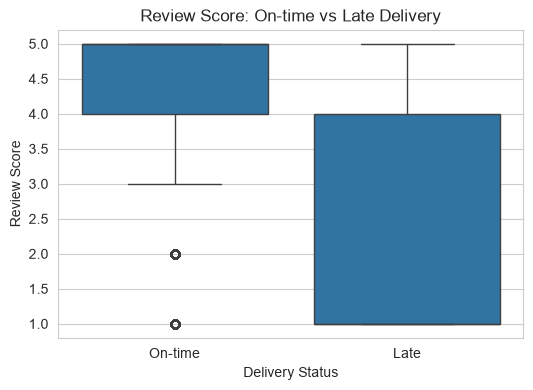

In [23]:
# simple chart to see it visually
plt.figure(figsize=(6, 4))
sns.boxplot(x=ecommerce_data['delivery_delay_days'] > 0, y=ecommerce_data['review_score'])
plt.xticks([0, 1], ['On-time', 'Late'])
plt.xlabel('Delivery Status')
plt.ylabel('Review Score')
plt.title('Review Score: On-time vs Late Delivery')
plt.show()

### Conclusion:
Delayed orders have an average review score of 2.27, compared with 4.29 for on-time/early orders. The t-test confirms that this difference is statistically significant.

## 2. Payment type distribution 

In [6]:
# Keep unique order and payment type
payment_data = ecommerce_data[['order_id', 'payment_type']].drop_duplicates()

payment_counts = payment_data['payment_type'].value_counts()

dominant_payment = payment_counts.index[0]

dominant_count = payment_counts.iloc[0]

dominant_percentage = (dominant_count / len(payment_data)) * 100

print("Dominant Payment Type:", dominant_payment)
print("Percentage:", round(dominant_percentage, 2), "%")

Dominant Payment Type: credit_card
Percentage: 76.65 %


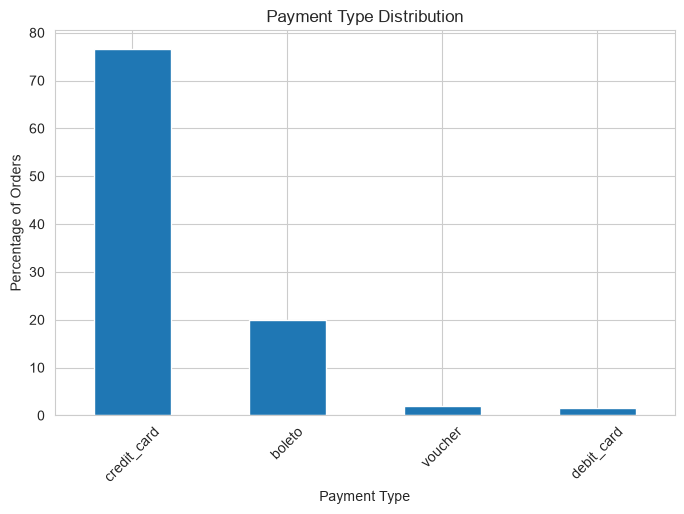

In [26]:
# Simple bar chart
payment_percentage = (
    payment_data['payment_type']
    .value_counts(normalize=True) * 100
)

plt.figure(figsize=(8, 5))

payment_percentage.plot(kind='bar')

plt.xlabel("Payment Type")
plt.ylabel("Percentage of Orders")
plt.title("Payment Type Distribution")

plt.xticks(rotation=45)

plt.show()

### Conclusion:
Credit card is the dominant payment method, accounting for approximately 76.65% of order-payment records.

## 3. Geographic analysis (revenue & delivery by state)

### Step 1 — Top revenue state

In [7]:
state_revenue = (
    ecommerce_data.groupby('customer_state')['price']
      .sum()
      .sort_values(ascending=False)
)

top_revenue_state = state_revenue.index[0]

print("Top Revenue State:", top_revenue_state)
print("Revenue:", round(state_revenue.iloc[0], 2))

Top Revenue State: SP
Revenue: 5202955.05


### Step 2 — Top delay state

In [9]:
order_delay = ecommerce_data[
    ['order_id', 'customer_state', 'delivery_delay_days']
].drop_duplicates('order_id')

state_delay = (
    order_delay.groupby('customer_state')['delivery_delay_days']
               .mean()
               .sort_values(ascending=False)
)

top_delay_state = state_delay.index[0]

print("Top Delay State:", top_delay_state)
print("Average Delay:", round(state_delay.iloc[0], 2), "days")

Top Delay State: AL
Average Delay: -8.71 days


### Top revenue state vs Top delay state

In [10]:
if top_revenue_state == top_delay_state:
    print("Yes - Top revenue state and top delay state are the same.")
else:
    print("No - Top revenue state and top delay state are different.")

No - Top revenue state and top delay state are different.


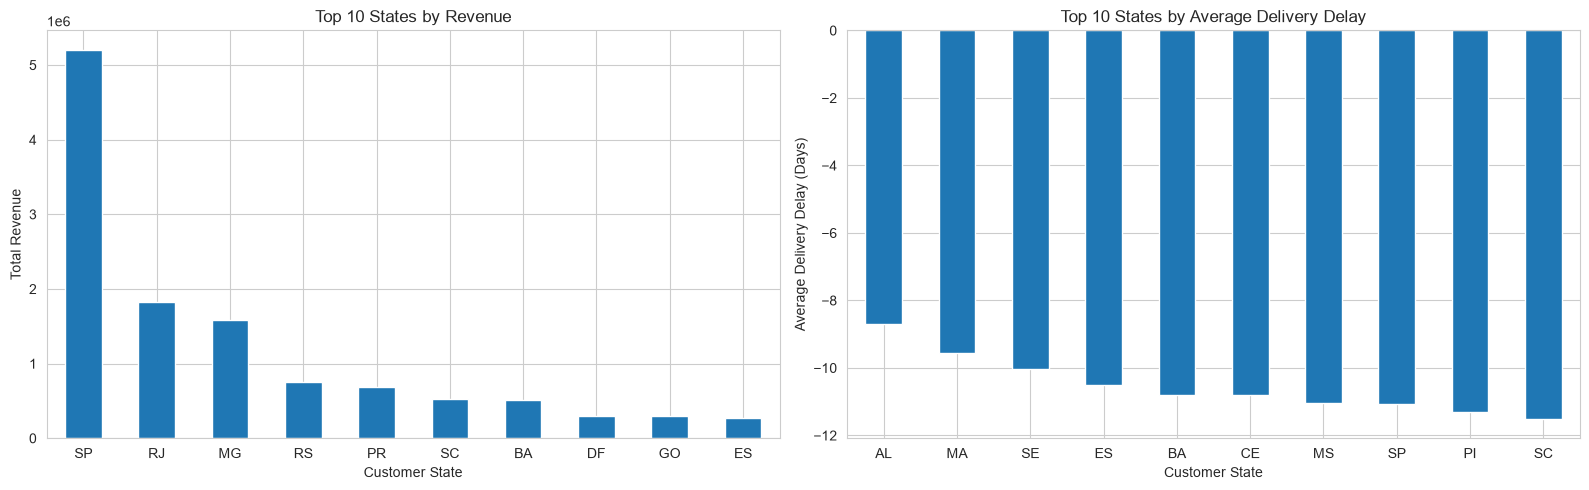

In [28]:
# simple side-by-side charts
top_10_revenue = state_revenue.head(10)

# Take top 10 delay states also
top_10_delay = state_delay.head(10)

# Create side-by-side charts
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1 - Top 10 Revenue States
top_10_revenue.plot(kind='bar', ax=ax[0])

ax[0].set_xlabel("Customer State")
ax[0].set_ylabel("Total Revenue")
ax[0].set_title("Top 10 States by Revenue")
ax[0].tick_params(axis='x', rotation=0)


# Chart 2 - Top 10 Delay States
top_10_delay.plot(kind='bar', ax=ax[1])

ax[1].set_xlabel("Customer State")
ax[1].set_ylabel("Average Delivery Delay (Days)")
ax[1].set_title("Top 10 States by Average Delivery Delay")
ax[1].tick_params(axis='x', rotation=0)


plt.tight_layout()
plt.show()

### Conclusion:
SP generates the highest revenue, while AL has the highest average delivery-delay value. Therefore, the highest-revenue state is not the state with the highest average delay.

## 4. Freight cost vs product price relationship

In [29]:
freight_data = ecommerce_data[
    ['order_id', 'order_item_id', 'price', 'freight_value']
].dropna()

high_freight = freight_data[
    freight_data['freight_value'] >
    (freight_data['price'] * 0.50)
]

percentage = (
    len(high_freight) / len(freight_data)
) * 100

print("Total Items:", len(freight_data))
print("Items with High Freight:", len(high_freight))
print("Percentage:", round(percentage, 2), "%")

Total Items: 112650
Items with High Freight: 18941
Percentage: 16.81 %


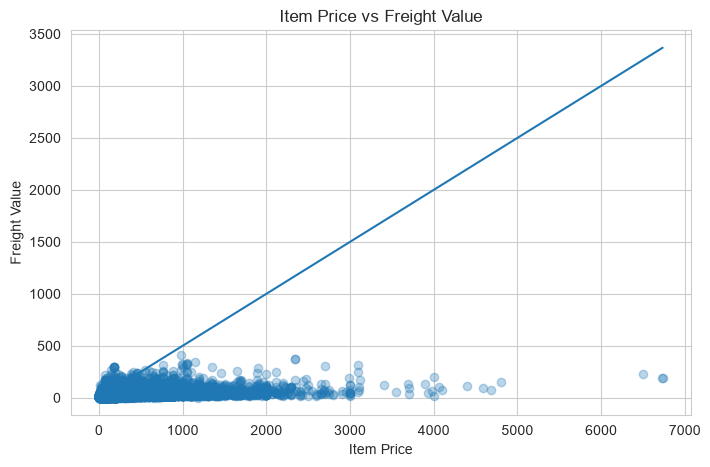

In [31]:
# simple scatter plot 

freight_data = ecommerce_data[
    ['price', 'freight_value']
].dropna()

plt.figure(figsize=(8, 5))

# Scatter plot
plt.scatter(
    freight_data['price'],
    freight_data['freight_value'],
    alpha=0.3
)

# 50% freight line
max_price = freight_data['price'].max()

plt.plot(
    [0, max_price],
    [0, max_price * 0.5]
)

plt.xlabel("Item Price")
plt.ylabel("Freight Value")
plt.title("Item Price vs Freight Value")

plt.show()

### Conclusion:
Approximately 16.81% of order items have freight charges greater than 50% of the item price, indicating that shipping costs are substantial relative to product value for a meaningful share of items.